#**HW1**
Data Analytics

Authors: Najafizadeh, Hatami, Ardi

#Import Necessary Library

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
import numpy as np
import torchvision
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms
import numpy as np
from PIL import Image
from google.colab import drive
import glob
from pathlib import Path

In [2]:
# run this to see all the outputs below each cell, not only the last instruction 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
# mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


#Part A

##Part A-1

In [4]:
# Load labels into a pandas DataFrame
labels_df = pd.read_csv('/content/drive/MyDrive/data/ByteToImage/trainLabels.csv')

# Path to the folder containing the images
images_dir = '/content/drive/MyDrive/data/ByteToImage/ByteToImage'

# Get list of image paths and labels
# X = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith('.png')]
X = glob.glob('/content/drive/MyDrive/data/ByteToImage/ByteToImage/*.png')

In [5]:
y = []
import pandas
df = pandas.read_csv('/content/drive/MyDrive/data/ByteToImage/trainLabels.csv')
for img in X :
    id = df[df['Id'] == str(Path(img).stem.__str__())]['Class'].iloc[0]
    y.append(id)

In [6]:
# Split data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=40)

In [7]:
# Define a custom function to load and transform data
def load_and_transform_data(X, y, transform):
    data = []
    for i in range(len(X)):
        img_path = X[i]
        img = Image.open(img_path).convert('RGB')
        if transform is not None:
            img = transform(img)
        label = y[i]-1 # labels are in [1,9], should be in [0,8]
        data.append((img, label))
    return data

In [8]:
# Load images and apply transformations # also you can use transforms.Resize((64, 64))
data_transforms = transforms.Compose([transforms.Grayscale(num_output_channels=1),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=(0.5, ), std=(0.5, ))])

train_data = load_and_transform_data(X_train, y_train, transform=data_transforms)
val_data = load_and_transform_data(X_val, y_val, transform=data_transforms)
test_data = load_and_transform_data(X_test, y_test, transform=data_transforms)

batch_size=128

trainloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
valloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)
testloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Training set size:", len(train_data))
print("Validation set size:", len(val_data))
print("Test set size:", len(test_data))
print(type(train_data), type(train_data[0]), type(train_data[0][0]))
print("image shape:", train_data[0][0].shape)
print("label type:", type(train_data[0][1]))
print(train_data[0][0].shape)


Training set size: 8688
Validation set size: 1086
Test set size: 1086
<class 'list'> <class 'tuple'> <class 'torch.Tensor'>
image shape: torch.Size([1, 32, 32])
label type: <class 'numpy.int64'>
torch.Size([1, 32, 32])


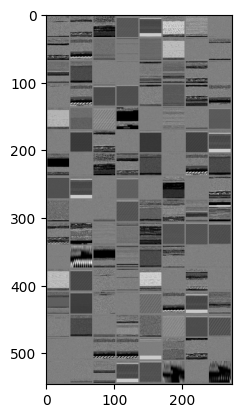

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# function to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = dataiter.__next__()

# show images
imshow(torchvision.utils.make_grid(images))

# print labels
print(''.join('%1s' % labels[j].numpy() for j in range(128)))

##Part A-2

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch.optim as optim

30711182075281280822500237115607181328512102121102708278112127208251000705817111260080221135127201321710385081112277180225011626


In [11]:
print("GPU available: {}".format(torch.cuda.is_available()))
if torch.cuda.is_available():
  device = 'cuda' 
else:
  device = 'cpu' 

GPU available: True


ParametricCNN with 4 CNN and 3 fully connected

In [12]:
class ParametricCNN(nn.Module):
    def __init__(self, num_classes=9, lr=0.001, reg=0.001, device='cpu'):
        super(ParametricCNN, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layer
        self.fc1 = nn.Linear(256 * 8 * 8 , 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

        # Hyperparameters
        self.lr = lr
        self.reg = reg
        self.num_classes = num_classes
        self.device = device

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.pool4(F.relu(self.conv4(x)))
        x = x.view(-1, 256 * 8 * 8 )
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x
    def configure_optimizers(self):
        optimizer = optim.SGD(self.parameters(), lr=self.lr, weight_decay=self.reg)
        return optimizer


ParametricCNN with 6 CNN and 3 fully connected and have batch normalization

In [13]:
class ParametricCNN_Deep(nn.Module):
    def __init__(self, num_classes=9, lr=0.001, reg=0.001, device='cpu'):
        super(ParametricCNN_Deep, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn2 = nn.BatchNorm2d(num_features=64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(num_features=128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn4 = nn.BatchNorm2d(num_features=256)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn5 = nn.BatchNorm2d(num_features=512)
        self.conv6 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.pool6 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn6 = nn.BatchNorm2d(num_features=512)
        # Fully connected layer
        self.fc1 = nn.Linear(2*2*512, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 64)
        self.bn8 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, num_classes)

        # Hyperparameters
        self.lr = lr
        self.reg = reg
        self.num_classes = num_classes
        self.device = device

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = self.pool5(F.relu(self.bn5(self.conv5(x))))
        x = self.pool6(F.relu(self.bn6(self.conv6(x))))
        x = x.view(-1, 512*2*2)
        x = F.relu(self.bn7(self.fc1(x)))
        x = F.relu(self.bn8(self.fc2(x)))
        x = F.softmax(self.fc3(x), dim=1)
        return x
    def configure_optimizers(self):
        optimizer = optim.SGD(self.parameters(), lr=self.lr, weight_decay=self.reg)
        return optimizer

#Part B

##Part B-1

In [14]:
net_lr_01 = ParametricCNN(lr=0.01, device=device).train()
net_lr_01.to(device)

optimizer = net_lr_01.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    net_lr_01 = net_lr_01.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_01(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            # print(images[0])
            # print(images[1])
            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')
del net_lr_01

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Loss: 2.201
Train Accuracy = 6.538%
Validation Accuracy = 6.446%
Test Accuracy = 5.249%
Starting Epoch: 2...
Loss: 2.200
Train Accuracy = 9.553%
Validation Accuracy = 8.656%
Test Accuracy = 8.195%
Starting Epoch: 3...
Loss: 2.200
Train Accuracy = 9.553%
Validation Accuracy = 8.656%
Test Accuracy = 8.195%
Starting Epoch: 4...
Loss: 2.199
Train Accuracy = 9.553%
Validation Accuracy = 8.656%
Test Accuracy = 8.195%
Starting Epoch: 5...
Loss: 2.198
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%
Starting Epoch: 6...
Loss: 2.197
Train Accuracy = 37.005%
Validation Accuracy = 36.096%
Test Accuracy = 39.134%
Starting Epoch: 7...
Loss: 2.197
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 8...
Loss: 2.196
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 9...
Loss: 2.195
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Star

##Part B-2

In [15]:
net_lr_001 = ParametricCNN(lr=0.001, device=device)
net_lr_001.to(device)
optimizer = net_lr_001.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_001 = []
loss_log_001 = []
train_accuracy_log_001 = []
test_accuracy_log_001 = []
validation_accuracy_log_001 = []

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_001(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_001(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_001(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_001(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_001.append(epoch_num)
    loss_log_001.append(actual_loss)
    train_accuracy_log_001.append(train_accuracy)
    validation_accuracy_log_001.append(validation_accuracy)
    test_accuracy_log_001.append(test_accuracy)

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Loss: 2.202
Train Accuracy = 5.433%
Validation Accuracy = 6.906%
Test Accuracy = 4.420%
Starting Epoch: 2...
Loss: 2.202
Train Accuracy = 11.004%
Validation Accuracy = 11.050%
Test Accuracy = 9.853%
Starting Epoch: 3...
Loss: 2.202
Train Accuracy = 13.847%
Validation Accuracy = 13.260%
Test Accuracy = 13.168%
Starting Epoch: 4...
Loss: 2.202
Train Accuracy = 14.250%
Validation Accuracy = 13.536%
Test Accuracy = 13.628%
Starting Epoch: 5...
Loss: 2.202
Train Accuracy = 14.250%
Validation Accuracy = 13.536%
Test Accuracy = 13.628%
Starting Epoch: 6...
Loss: 2.202
Train Accuracy = 14.250%
Validation Accuracy = 13.536%
Test Accuracy = 13.628%
Starting Epoch: 7...
Loss: 2.202
Train Accuracy = 14.250%
Validation Accuracy = 13.536%
Test Accuracy = 13.628%
Starting Epoch: 8...
Loss: 2.202
Train Accuracy = 14.250%
Validation Accuracy = 13.536%
Test Accuracy = 13.628%
Starting Epoch: 9...
Loss: 2.202
Train Accuracy = 14.250%
Validation Accuracy = 13.536%
Test Accuracy = 13.6

In [16]:
net_lr_1 = ParametricCNN(lr=0.1, device=device).train()
net_lr_1.to(device)

optimizer = net_lr_1.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_1 = []
loss_log_1 = []
train_accuracy_log_1 = []
test_accuracy_log_1 = []
validation_accuracy_log_1 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    net_lr_1 = net_lr_1.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_1(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    net_lr_1 = net_lr_1.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = net_lr_1(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    net_lr_1 = net_lr_1.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_1(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_1(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_1.append(epoch_num)
    loss_log_1.append(actual_loss)
    train_accuracy_log_1.append(train_accuracy)
    validation_accuracy_log_1.append(validation_accuracy)
    test_accuracy_log_1.append(test_accuracy)

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Loss: 2.197
Train Accuracy = 14.250%
Validation Accuracy = 13.536%
Test Accuracy = 13.628%
Starting Epoch: 2...
Loss: 2.190
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Loss: 2.177
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 4...
Loss: 2.092
Train Accuracy = 43.589%
Validation Accuracy = 41.989%
Test Accuracy = 46.777%
Starting Epoch: 5...
Loss: 1.923
Train Accuracy = 48.170%
Validation Accuracy = 47.145%
Test Accuracy = 51.842%
Starting Epoch: 6...
Loss: 1.901
Train Accuracy = 48.354%
Validation Accuracy = 47.514%
Test Accuracy = 51.934%
Starting Epoch: 7...
Loss: 1.891
Train Accuracy = 48.550%
Validation Accuracy = 47.606%
Test Accuracy = 52.118%
Starting Epoch: 8...
Loss: 1.889
Train Accuracy = 48.930%
Validation Accuracy = 48.527%
Test Accuracy = 52.026%
Starting Epoch: 9...
Loss: 1.887
Train Accuracy = 48.872%
Validation Accuracy = 48.619%
Test Accuracy = 

##Part B-3

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with lr=.01')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with lr=.001')

...

(0.0, 100.0)

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with lr=.1')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

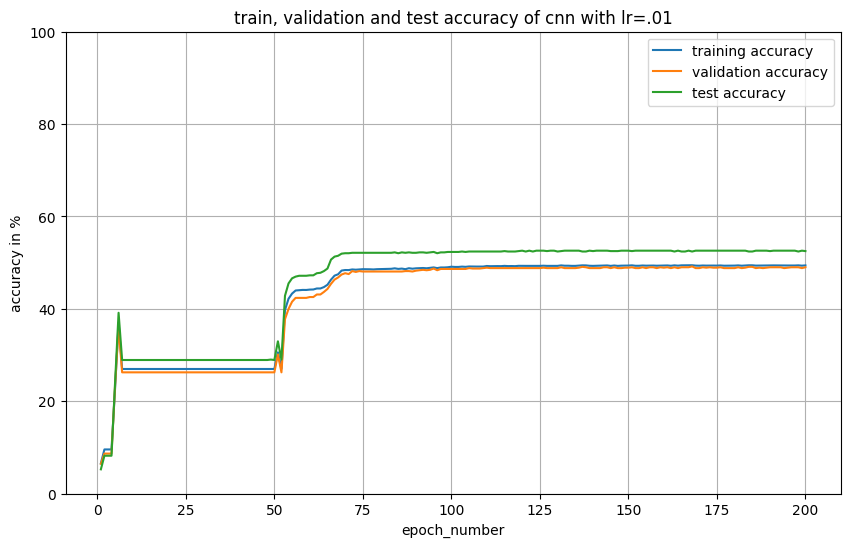

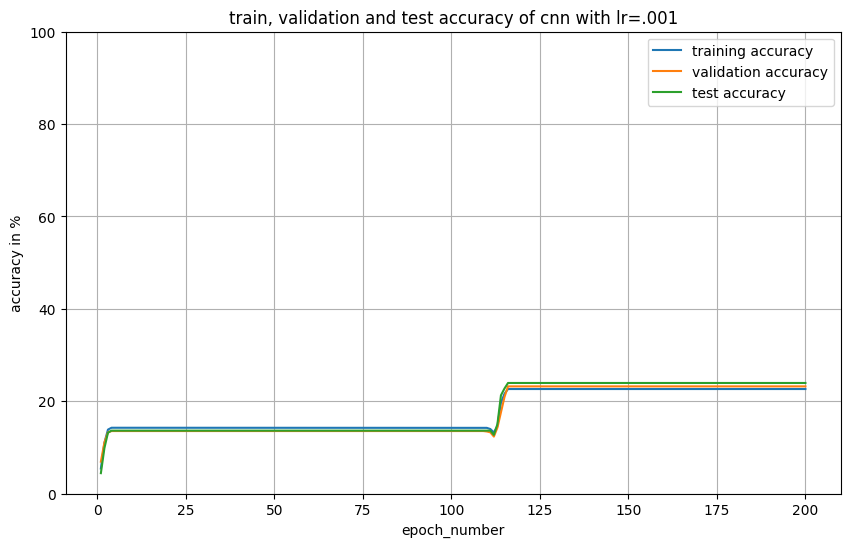

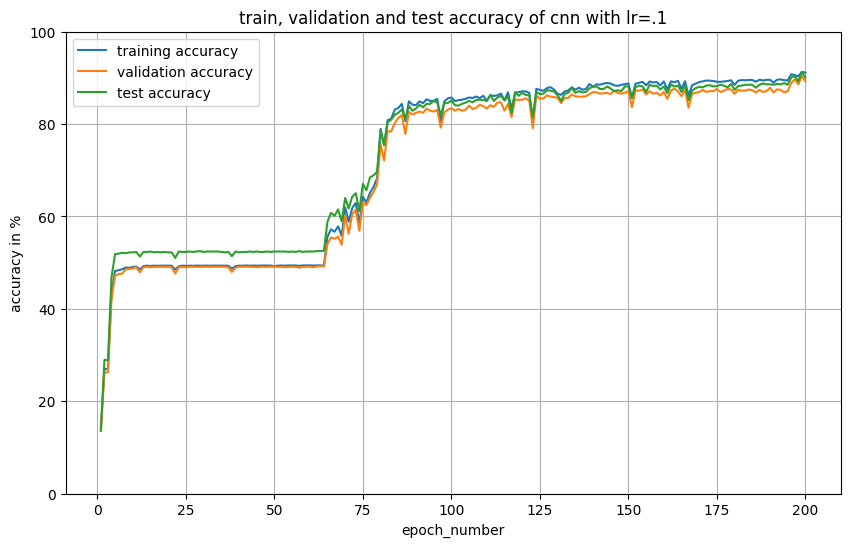

In [17]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN with learning rate of 0.01
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with lr=.01')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

#plotting train, validation and test accuracies for ParametricCNN with learning rate of 0.001
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_001, train_accuracy_log_001, label='training accuracy')
ax.plot(epoch_log_001, validation_accuracy_log_001, label='validation accuracy')
ax.plot(epoch_log_001, test_accuracy_log_001, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with lr=.001')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

#plotting train, validation and test accuracies for ParametricCNN with learning rate of 0.1
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_1, train_accuracy_log_1, label='training accuracy')
ax.plot(epoch_log_1, validation_accuracy_log_1, label='validation accuracy')
ax.plot(epoch_log_1, test_accuracy_log_1, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with lr=.1')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

#Part B-1-*

In [18]:
net_lr_01 = ParametricCNN_Deep(lr=0.01, device=device).train()
net_lr_01.to(device)

optimizer = net_lr_01.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 50

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    net_lr_01 = net_lr_01.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_01(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            # print(images[0])
            # print(images[1])
            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')

ParametricCNN_Deep(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool5): MaxPool2d(kernel_size=2, stride=2, padding=0, dila

Starting Epoch: 1...
Loss: 1.918
Train Accuracy = 82.953%
Validation Accuracy = 80.479%
Test Accuracy = 82.965%
Starting Epoch: 2...
Loss: 1.714
Train Accuracy = 85.359%
Validation Accuracy = 83.610%
Test Accuracy = 85.359%
Starting Epoch: 3...
Loss: 1.638
Train Accuracy = 88.156%
Validation Accuracy = 86.832%
Test Accuracy = 87.661%
Starting Epoch: 4...
Loss: 1.593
Train Accuracy = 90.424%
Validation Accuracy = 89.503%
Test Accuracy = 90.331%
Starting Epoch: 5...
Loss: 1.562
Train Accuracy = 91.506%
Validation Accuracy = 90.608%
Test Accuracy = 91.344%
Starting Epoch: 6...
Loss: 1.539
Train Accuracy = 93.244%
Validation Accuracy = 92.726%
Test Accuracy = 93.002%
Starting Epoch: 7...
Loss: 1.519
Train Accuracy = 93.992%
Validation Accuracy = 93.462%
Test Accuracy = 93.738%
Starting Epoch: 8...
Loss: 1.503
Train Accuracy = 95.373%
Validation Accuracy = 94.751%
Test Accuracy = 94.936%
Starting Epoch: 9...
Loss: 1.486
Train Accuracy = 96.179%
Validation Accuracy = 95.396%
Test Accuracy = 

# Part B-2-*

In [19]:
net_lr_001 = ParametricCNN_Deep(lr=0.001, device=device)
net_lr_001.to(device)
optimizer = net_lr_001.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 50

epoch_log_001 = []
loss_log_001 = []
train_accuracy_log_001 = []
test_accuracy_log_001 = []
validation_accuracy_log_001 = []

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_001(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_001(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_001(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_001(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_001.append(epoch_num)
    loss_log_001.append(actual_loss)
    train_accuracy_log_001.append(train_accuracy)
    validation_accuracy_log_001.append(validation_accuracy)
    test_accuracy_log_001.append(test_accuracy)

print('Finished Training')

ParametricCNN_Deep(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool5): MaxPool2d(kernel_size=2, stride=2, padding=0, dila

Starting Epoch: 1...
Loss: 2.082
Train Accuracy = 63.709%
Validation Accuracy = 61.878%
Test Accuracy = 64.641%
Starting Epoch: 2...
Loss: 1.971
Train Accuracy = 67.599%
Validation Accuracy = 65.285%
Test Accuracy = 67.956%
Starting Epoch: 3...
Loss: 1.924
Train Accuracy = 69.993%
Validation Accuracy = 67.587%
Test Accuracy = 70.166%
Starting Epoch: 4...
Loss: 1.889
Train Accuracy = 72.767%
Validation Accuracy = 70.074%
Test Accuracy = 71.455%
Starting Epoch: 5...
Loss: 1.862
Train Accuracy = 74.827%
Validation Accuracy = 71.731%
Test Accuracy = 73.757%
Starting Epoch: 6...
Loss: 1.838
Train Accuracy = 77.164%
Validation Accuracy = 73.573%
Test Accuracy = 76.243%
Starting Epoch: 7...
Loss: 1.819
Train Accuracy = 79.109%
Validation Accuracy = 75.783%
Test Accuracy = 78.177%
Starting Epoch: 8...
Loss: 1.801
Train Accuracy = 80.007%
Validation Accuracy = 76.519%
Test Accuracy = 79.650%
Starting Epoch: 9...
Loss: 1.785
Train Accuracy = 81.135%
Validation Accuracy = 77.440%
Test Accuracy = 

# Part B-3-*

Text(0.5, 1.0, 'train, validation and test accuracy of cnn_Deep with lr=.01')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

Text(0.5, 1.0, 'train, validation and test accuracy of cnn_Deep with lr=.001')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

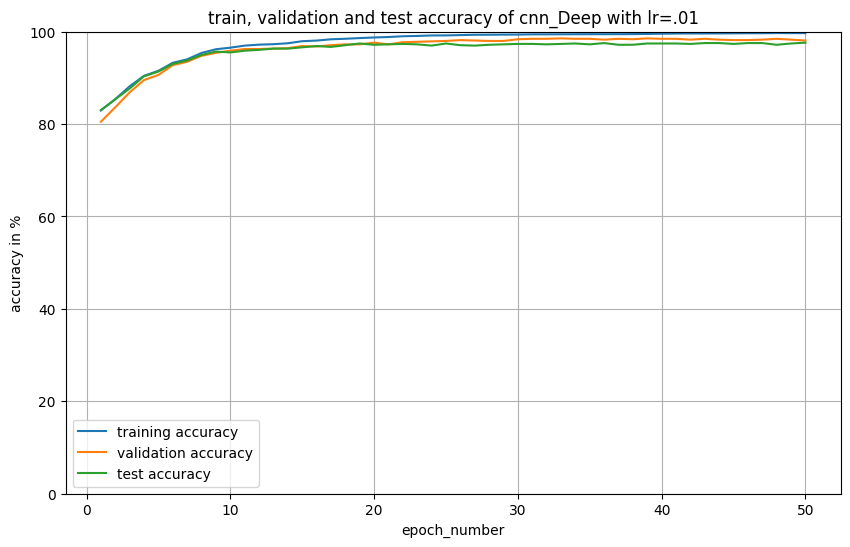

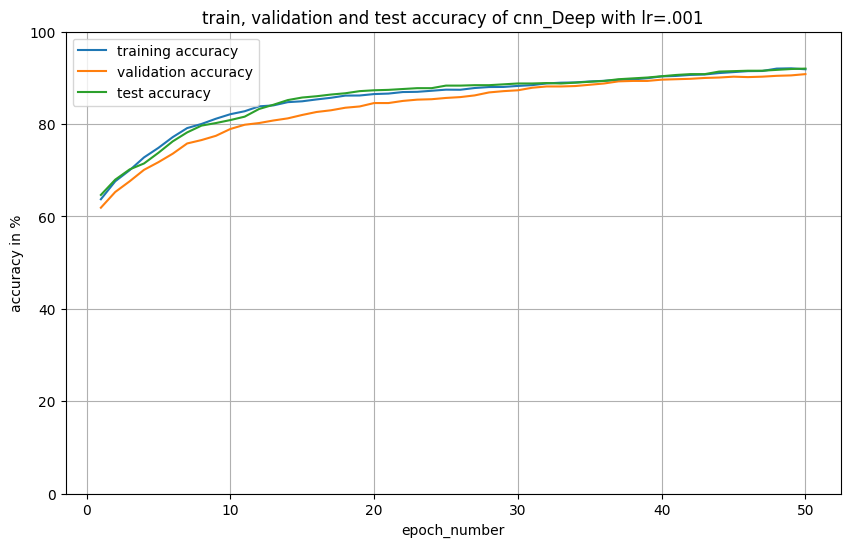

In [20]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN with learning rate of 0.01
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn_Deep with lr=.01')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

#plotting train, validation and test accuracies for ParametricCNN with learning rate of 0.001
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_001, train_accuracy_log_001, label='training accuracy')
ax.plot(epoch_log_001, validation_accuracy_log_001, label='validation accuracy')
ax.plot(epoch_log_001, test_accuracy_log_001, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn_Deep with lr=.001')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

##Part B-4

In [21]:
from torch.optim.lr_scheduler import StepLR

net_lr_scheduled = ParametricCNN(lr=0.1, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.1)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.1
Loss: 2.199
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%
Starting Epoch: 2...
Learning rate:  0.1
Loss: 2.191
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%
Starting Epoch: 3...
Learning rate:  0.1
Loss: 2.159
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%
Starting Epoch: 4...
Learning rate:  0.1
Loss: 2.085
Train Accuracy = 21.777%
Validation Accuracy = 21.731%
Test Accuracy = 23.573%
Starting Epoch: 5...
Learning rate:  0.1
Loss: 1.960
Train Accuracy = 48.193%
Validation Accuracy = 47.145%
Test Accuracy = 51.842%
Starting Epoch: 6...
Learning rate:  0.1
Loss: 1.893
Train Accuracy = 48.573%
Validation Accuracy = 48.066%
Test Accuracy = 52.118%
Starting Epoch: 7...
Learning rate:  0.1
Loss: 1.891
Train Accuracy = 48.538%
Validation Accuracy = 48.066%
Test Accuracy = 52.118%
Starting Epoch: 8...
Learning rate:  0.1
Loss: 1.889
Train Accuracy = 47.963

##Part B-5

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with scheduled lr=.1 every 50 epoch *.1')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

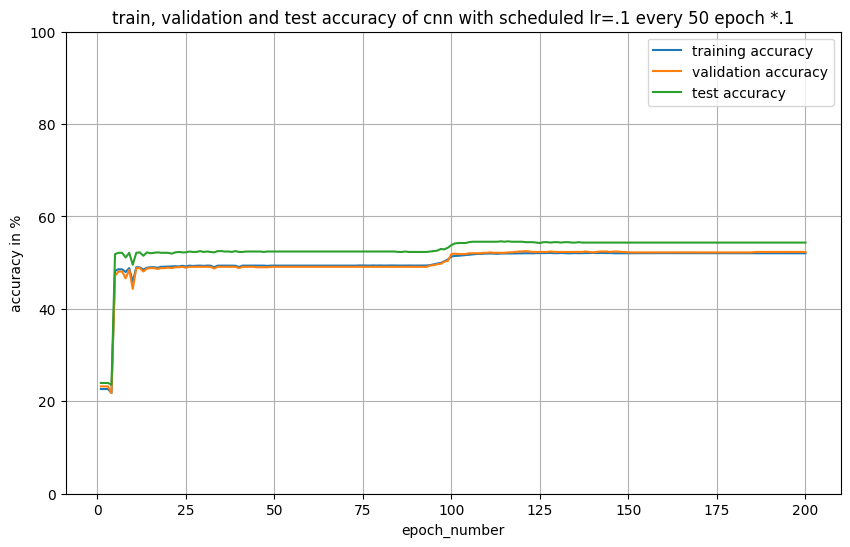

In [22]:

#plotting train, validation and test accuracies for ParametricCNN with scheduled learning rate 
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_sch, train_accuracy_log_sch, label='training accuracy')
ax.plot(epoch_log_sch, validation_accuracy_log_sch, label='validation accuracy')
ax.plot(epoch_log_sch, test_accuracy_log_sch, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with scheduled lr=.1 every 50 epoch *.1')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

##Part B-5-*

In [23]:
from torch.optim.lr_scheduler import StepLR

net_lr_scheduled = ParametricCNN(lr=0.01, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.1)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.01
Loss: 2.201
Train Accuracy = 11.268%
Validation Accuracy = 10.958%
Test Accuracy = 11.971%
Starting Epoch: 2...
Learning rate:  0.01
Loss: 2.200
Train Accuracy = 11.268%
Validation Accuracy = 10.958%
Test Accuracy = 11.971%
Starting Epoch: 3...
Learning rate:  0.01
Loss: 2.200
Train Accuracy = 11.268%
Validation Accuracy = 10.958%
Test Accuracy = 11.971%
Starting Epoch: 4...
Learning rate:  0.01
Loss: 2.199
Train Accuracy = 11.268%
Validation Accuracy = 10.958%
Test Accuracy = 11.971%
Starting Epoch: 5...
Learning rate:  0.01
Loss: 2.198
Train Accuracy = 11.268%
Validation Accuracy = 10.958%
Test Accuracy = 11.971%
Starting Epoch: 6...
Learning rate:  0.01
Loss: 2.198
Train Accuracy = 11.268%
Validation Accuracy = 10.958%
Test Accuracy = 11.971%
Starting Epoch: 7...
Learning rate:  0.01
Loss: 2.197
Train Accuracy = 11.268%
Validation Accuracy = 10.958%
Test Accuracy = 11.971%
Starting Epoch: 8...
Learning rate:  0.01
Loss: 2.196
Train Accuracy 

##Part B-5-*

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with scheduled lr=.01 every 50 epoch *.1')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

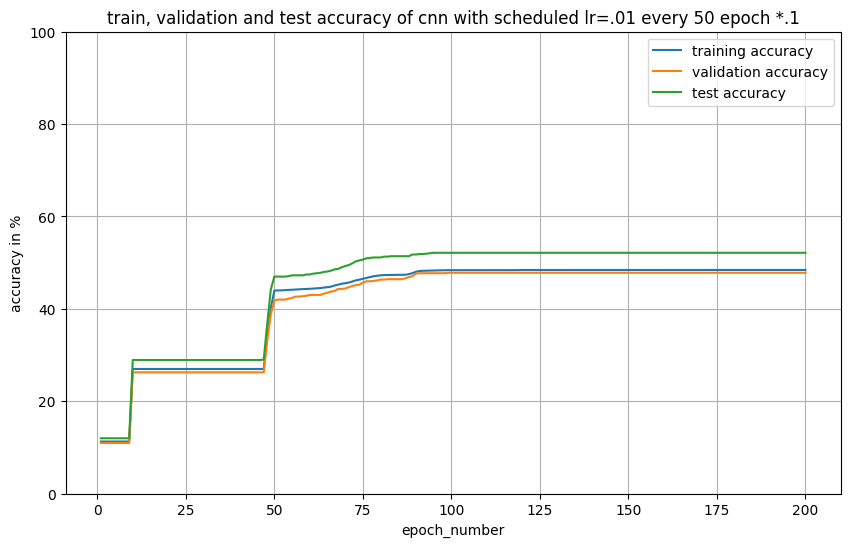

In [24]:

#plotting train, validation and test accuracies for ParametricCNN with scheduled learning rate 
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_sch, train_accuracy_log_sch, label='training accuracy')
ax.plot(epoch_log_sch, validation_accuracy_log_sch, label='validation accuracy')
ax.plot(epoch_log_sch, test_accuracy_log_sch, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with scheduled lr=.01 every 50 epoch *.1')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

# Part B-5-**

In [25]:
from torch.optim.lr_scheduler import StepLR

net_lr_scheduled = ParametricCNN(lr=0.1, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 300

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=150, gamma=0.1)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.1
Loss: 2.199
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%
Starting Epoch: 2...
Learning rate:  0.1
Loss: 2.192
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Learning rate:  0.1
Loss: 2.181
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 4...
Learning rate:  0.1
Loss: 2.105
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 5...
Learning rate:  0.1
Loss: 2.032
Train Accuracy = 43.646%
Validation Accuracy = 41.529%
Test Accuracy = 46.501%
Starting Epoch: 6...
Learning rate:  0.1
Loss: 1.937
Train Accuracy = 44.061%
Validation Accuracy = 42.357%
Test Accuracy = 46.777%
Starting Epoch: 7...
Learning rate:  0.1
Loss: 1.851
Train Accuracy = 61.936%
Validation Accuracy = 57.551%
Test Accuracy = 63.352%
Starting Epoch: 8...
Learning rate:  0.1
Loss: 1.807
Train Accuracy = 62.109

# Part B-5-**

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with scheduled lr=.1 every 150 epoch *.1')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

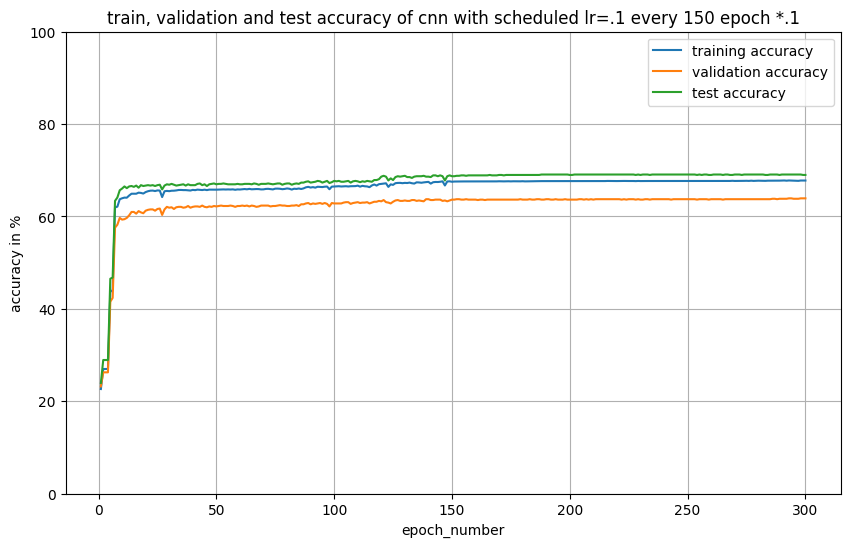

In [26]:
#plotting train, validation and test accuracies for ParametricCNN with scheduled learning rate 
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_sch, train_accuracy_log_sch, label='training accuracy')
ax.plot(epoch_log_sch, validation_accuracy_log_sch, label='validation accuracy')
ax.plot(epoch_log_sch, test_accuracy_log_sch, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with scheduled lr=.1 every 150 epoch *.1')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

##Part B-6

In [27]:
net_lr_scheduled = ParametricCNN(lr=0.1, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.1
Loss: 2.199
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 2...
Learning rate:  0.1
Loss: 2.192
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Learning rate:  0.1
Loss: 2.181
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 4...
Learning rate:  0.1
Loss: 2.127
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 29.006%
Starting Epoch: 5...
Learning rate:  0.1
Loss: 2.078
Train Accuracy = 45.166%
Validation Accuracy = 44.107%
Test Accuracy = 48.435%
Starting Epoch: 6...
Learning rate:  0.1
Loss: 1.928
Train Accuracy = 47.122%
Validation Accuracy = 45.948%
Test Accuracy = 50.552%
Starting Epoch: 7...
Learning rate:  0.1
Loss: 1.909
Train Accuracy = 48.147%
Validation Accuracy = 47.330%
Test Accuracy = 51.565%
Starting Epoch: 8...
Learning rate:  0.1
Loss: 1.889
Train Accuracy = 48.803

In [28]:
net_lr_scheduled = ParametricCNN(lr=0.2, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.2
Loss: 2.193
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 2...
Learning rate:  0.2
Loss: 2.168
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Learning rate:  0.2
Loss: 2.090
Train Accuracy = 22.514%
Validation Accuracy = 22.744%
Test Accuracy = 23.849%
Starting Epoch: 4...
Learning rate:  0.2
Loss: 1.973
Train Accuracy = 48.147%
Validation Accuracy = 46.961%
Test Accuracy = 51.565%
Starting Epoch: 5...
Learning rate:  0.2
Loss: 1.893
Train Accuracy = 48.354%
Validation Accuracy = 47.422%
Test Accuracy = 51.934%
Starting Epoch: 6...
Learning rate:  0.2
Loss: 1.898
Train Accuracy = 48.642%
Validation Accuracy = 47.882%
Test Accuracy = 52.118%
Starting Epoch: 7...
Learning rate:  0.2
Loss: 1.889
Train Accuracy = 49.022%
Validation Accuracy = 48.711%
Test Accuracy = 52.026%
Starting Epoch: 8...
Learning rate:  0.2
Loss: 1.890
Train Accuracy = 47.698

In [29]:
net_lr_scheduled = ParametricCNN(lr=0.1, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.8)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.1
Loss: 2.201
Train Accuracy = 14.250%
Validation Accuracy = 13.536%
Test Accuracy = 13.628%
Starting Epoch: 2...
Learning rate:  0.1
Loss: 2.194
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Learning rate:  0.1
Loss: 2.186
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 4...
Learning rate:  0.1
Loss: 2.171
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 5...
Learning rate:  0.1
Loss: 2.078
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 6...
Learning rate:  0.1
Loss: 1.974
Train Accuracy = 44.383%
Validation Accuracy = 43.002%
Test Accuracy = 47.606%
Starting Epoch: 7...
Learning rate:  0.1
Loss: 1.857
Train Accuracy = 62.086%
Validation Accuracy = 58.932%
Test Accuracy = 64.365%
Starting Epoch: 8...
Learning rate:  0.1
Loss: 1.761
Train Accuracy = 62.465

In [30]:
net_lr_scheduled = ParametricCNN(lr=0.5, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.5
Loss: 2.152
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 2...
Learning rate:  0.5
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Learning rate:  0.5
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 4...
Learning rate:  0.5
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 5...
Learning rate:  0.5
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 6...
Learning rate:  0.5
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 7...
Learning rate:  0.5
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 8...
Learning rate:  0.5
Loss: 2.106
Train Accuracy = 26.968

In [31]:
net_lr_scheduled = ParametricCNN(lr=0.9, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.1)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.9
Loss: 2.135
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 2...
Learning rate:  0.9
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Learning rate:  0.9
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 4...
Learning rate:  0.9
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 5...
Learning rate:  0.9
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 6...
Learning rate:  0.9
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 7...
Learning rate:  0.9
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 8...
Learning rate:  0.9
Loss: 2.106
Train Accuracy = 26.968

In [32]:
net_lr_scheduled = ParametricCNN(lr=0.3, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.25)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.3
Loss: 2.181
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 2...
Learning rate:  0.3
Loss: 2.009
Train Accuracy = 46.835%
Validation Accuracy = 45.304%
Test Accuracy = 50.368%
Starting Epoch: 3...
Learning rate:  0.3
Loss: 1.895
Train Accuracy = 48.400%
Validation Accuracy = 47.514%
Test Accuracy = 51.105%
Starting Epoch: 4...
Learning rate:  0.3
Loss: 1.886
Train Accuracy = 49.217%
Validation Accuracy = 49.079%
Test Accuracy = 52.302%
Starting Epoch: 5...
Learning rate:  0.3
Loss: 1.949
Train Accuracy = 47.261%
Validation Accuracy = 46.041%
Test Accuracy = 50.460%
Starting Epoch: 6...
Learning rate:  0.3
Loss: 1.890
Train Accuracy = 48.918%
Validation Accuracy = 48.527%
Test Accuracy = 51.565%
Starting Epoch: 7...
Learning rate:  0.3
Loss: 1.885
Train Accuracy = 49.240%
Validation Accuracy = 48.987%
Test Accuracy = 52.394%
Starting Epoch: 8...
Learning rate:  0.3
Loss: 1.878
Train Accuracy = 49.332

In [33]:
net_lr_scheduled = ParametricCNN(lr=0.6, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.6)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.6
Loss: 2.136
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 2...
Learning rate:  0.6
Loss: 2.064
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Learning rate:  0.6
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 4...
Learning rate:  0.6
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 5...
Learning rate:  0.6
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 6...
Learning rate:  0.6
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 7...
Learning rate:  0.6
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 8...
Learning rate:  0.6
Loss: 2.106
Train Accuracy = 26.968

In [34]:
net_lr_scheduled = ParametricCNN(lr=0.1, device=device)
net_lr_scheduled.to(device)
optimizer = net_lr_scheduled.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_sch = []
loss_log_sch = []
train_accuracy_log_sch = []
test_accuracy_log_sch = []
validation_accuracy_log_sch = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.9)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_scheduled(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_scheduled(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_sch.append(epoch_num)
    loss_log_sch.append(actual_loss)
    train_accuracy_log_sch.append(train_accuracy)
    validation_accuracy_log_sch.append(validation_accuracy)
    test_accuracy_log_sch.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.1
Loss: 2.198
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 2...
Learning rate:  0.1
Loss: 2.189
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Learning rate:  0.1
Loss: 2.165
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 4...
Learning rate:  0.1
Loss: 2.045
Train Accuracy = 38.513%
Validation Accuracy = 37.753%
Test Accuracy = 42.634%
Starting Epoch: 5...
Learning rate:  0.1
Loss: 1.948
Train Accuracy = 54.627%
Validation Accuracy = 53.499%
Test Accuracy = 58.379%
Starting Epoch: 6...
Learning rate:  0.1
Loss: 1.822
Train Accuracy = 61.430%
Validation Accuracy = 58.471%
Test Accuracy = 64.549%
Starting Epoch: 7...
Learning rate:  0.1
Loss: 1.768
Train Accuracy = 64.399%
Validation Accuracy = 61.234%
Test Accuracy = 67.680%
Starting Epoch: 8...
Learning rate:  0.1
Loss: 1.727
Train Accuracy = 66.321

#Part C

##Part C-1

In [35]:
epoch_logs_c1=[]
loss_logs_c1 = []
train_accuracy_logs_c1 = []
test_accuracy_logs_c1 = []
validation_accuracy_logs_c1 = []

for weight_decay in list(i/10 for i in range(11)):
    print(f'reg={weight_decay}')
    net_lr_scheduled_reg = ParametricCNN(lr=0.05, reg=weight_decay, device=device)
    net_lr_scheduled_reg.to(device)
    optimizer = net_lr_scheduled_reg.configure_optimizers()

    criterion = nn.CrossEntropyLoss()

    epochs = 20

    epoch_log_sch_reg = []
    loss_log_sch_reg = []
    train_accuracy_log_sch_reg = []
    test_accuracy_log_sch_reg = []
    validation_accuracy_log_sch_reg = []

    scheduler = StepLR(optimizer, step_size=50, gamma=0.9)

    for epoch in range(epochs):  
        print('\n'+f'Starting Epoch: {epoch+1}...')

        running_loss = 0.0

        print("Learning rate: ", optimizer.param_groups[0]['lr'])

        for i, data in enumerate(trainloader, 0):
            inputs, labels = data

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = net_lr_scheduled_reg(inputs) # Forward Propagation 
            loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
            loss.backward() # Back propagate to obtain the new gradients for all nodes
            optimizer.step() # Update the gradients/weights

            running_loss += loss.item()

        correct = 0 
        total = 0 

        with torch.no_grad():
            for data in trainloader:
                images, labels = data

                images = images.to(device)
                labels = labels.to(device)

                outputs = net_lr_scheduled_reg(images)

                _, predicted = torch.max(outputs.data, dim = 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            train_accuracy = 100 * correct / total
            epoch_num = epoch + 1
            NumOfBatches=len(train_data)/batch_size
            actual_loss = running_loss / NumOfBatches

            print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
            running_loss = 0.0

        correct = 0 
        total = 0 

        with torch.no_grad():
            for data in valloader:
                images, labels = data

                images = images.to(device)
                labels = labels.to(device)

                outputs = net_lr_scheduled_reg(images)

                _, predicted = torch.max(outputs.data, dim = 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            validation_accuracy = 100 * correct / total

            print(f'Validation Accuracy = {validation_accuracy:.3f}%')

        correct = 0 
        total = 0 

        with torch.no_grad():
            for data in testloader:
                images, labels = data

                images = images.to(device)
                labels = labels.to(device)

                outputs = net_lr_scheduled_reg(images)

                _, predicted = torch.max(outputs.data, dim = 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            test_accuracy = 100 * correct / total

            print(f'Test Accuracy = {test_accuracy:.3f}%')

        epoch_log_sch_reg.append(epoch_num)
        loss_log_sch_reg.append(actual_loss)
        train_accuracy_log_sch_reg.append(train_accuracy)
        validation_accuracy_log_sch_reg.append(validation_accuracy)
        test_accuracy_log_sch_reg.append(test_accuracy)

        # adjusting learning rate using scheduler
        scheduler.step()

    epoch_logs_c1.append(epoch_log_sch_reg)
    loss_logs_c1.append(loss_log_sch_reg)
    train_accuracy_logs_c1.append(train_accuracy_log_sch_reg)
    test_accuracy_logs_c1.append(test_accuracy_log_sch_reg)
    validation_accuracy_logs_c1.append(validation_accuracy_log_sch_reg)
    
    print('Finished Training')

print('finished reg parameter values')


reg=0.0


ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)


Starting Epoch: 1...
Learning rate:  0.05
Loss: 2.199
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 2...
Learning rate:  0.05
Loss: 2.195
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 3...
Learning rate:  0.05
Loss: 2.191
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 4...
Learning rate:  0.05
Loss: 2.186
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 5...
Learning rate:  0.05
Loss: 2.181
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 6...
Learning rate:  0.05
Loss: 2.173
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 7...
Learning rate:  0.05
Loss: 2.150
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 8...
Learning rate:  0.05
Loss: 2.086
Train A

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)


Starting Epoch: 1...
Learning rate:  0.05
Loss: 2.199
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 2...
Learning rate:  0.05
Loss: 2.197
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 3...
Learning rate:  0.05
Loss: 2.196
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 4...
Learning rate:  0.05
Loss: 2.195
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 5...
Learning rate:  0.05
Loss: 2.195
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 6...
Learning rate:  0.05
Loss: 2.194
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 7...
Learning rate:  0.05
Loss: 2.194
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 8...
Learning rate:  0.05
Loss: 2.194
Train A

...


Starting Epoch: 1...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%

Starting Epoch: 2...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 3...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 4...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 5...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 6...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 7...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 8...
Learning rate:  0.05
Loss: 2.200
Train A

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)


Starting Epoch: 1...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 2...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 3...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 4...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 5...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 6...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 7...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 8...
Learning rate:  0.05
Loss: 2.200
Train A

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)


Starting Epoch: 1...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%

Starting Epoch: 2...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 3...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 4...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 5...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 6...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 7...
Learning rate:  0.05
Loss: 2.200
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 8...
Learning rate:  0.05
Loss: 2.200
Train A

#Part C-2

Text(0.5, 1.0, 'train accuracy of cnn with reg = 0:0.1:1')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

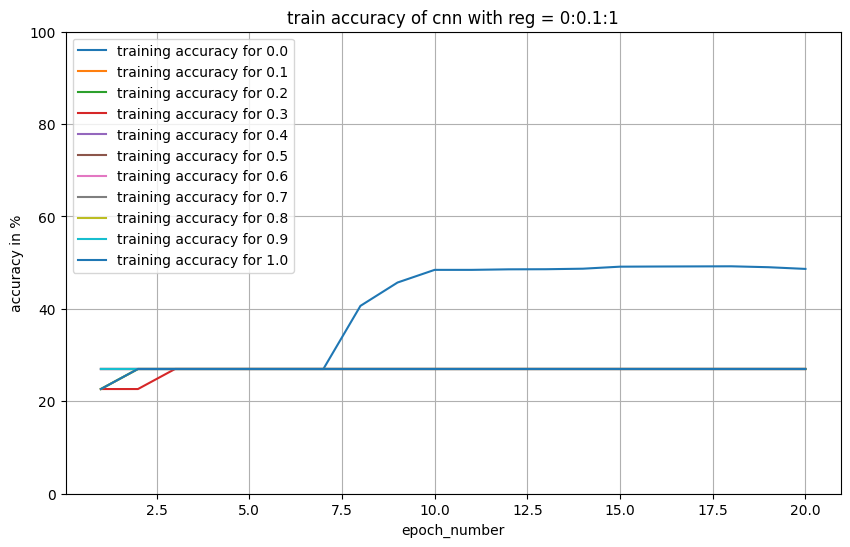

In [36]:
#plotting train accuracies for ParametricCNN with change reg
fig, ax = plt.subplots(figsize=(10, 6))
for weight_decay in list(i/10 for i in range(11)):
    ax.plot(epoch_log_sch_reg, train_accuracy_logs_c1[int(weight_decay*10)], label='training accuracy for '+ str(weight_decay))

ax.set_title('train accuracy of cnn with reg = 0:0.1:1')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

Text(0.5, 1.0, ' validation accuracy of cnn with reg = 0:0.1:1')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

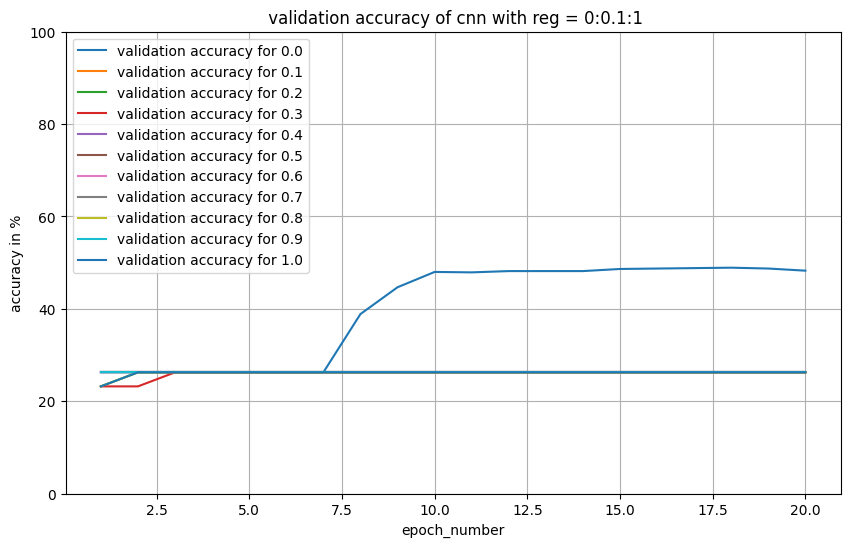

In [37]:
#plotting validation accuracies for ParametricCNN with change reg
fig, ax = plt.subplots(figsize=(10, 6))
for weight_decay in list(i/10 for i in range(11)):
    ax.plot(epoch_log_sch_reg, validation_accuracy_logs_c1[int(weight_decay*10)], label='validation accuracy for '+ str(weight_decay))

ax.set_title(' validation accuracy of cnn with reg = 0:0.1:1')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

Text(0.5, 1.0, 'test accuracy of cnn with reg = 0:0.1:1')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

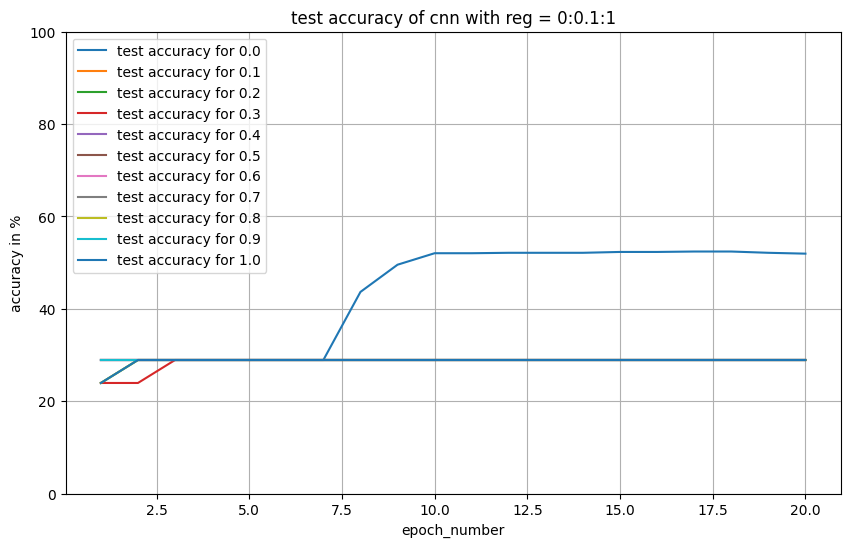

In [38]:
#plotting test accuracies for ParametricCNN with change reg
fig, ax = plt.subplots(figsize=(10, 6))
for weight_decay in list(i/10 for i in range(11)):
    ax.plot(epoch_log_sch_reg, test_accuracy_logs_c1[int(weight_decay*10)], label='test accuracy for '+ str(weight_decay))

ax.set_title('test accuracy of cnn with reg = 0:0.1:1')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

#Part C-3

Text(0.5, 1.0, 'accuracy of cnn with reg = 0:0.1:1')

Text(0.5, 0, 'weight_decay *10')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

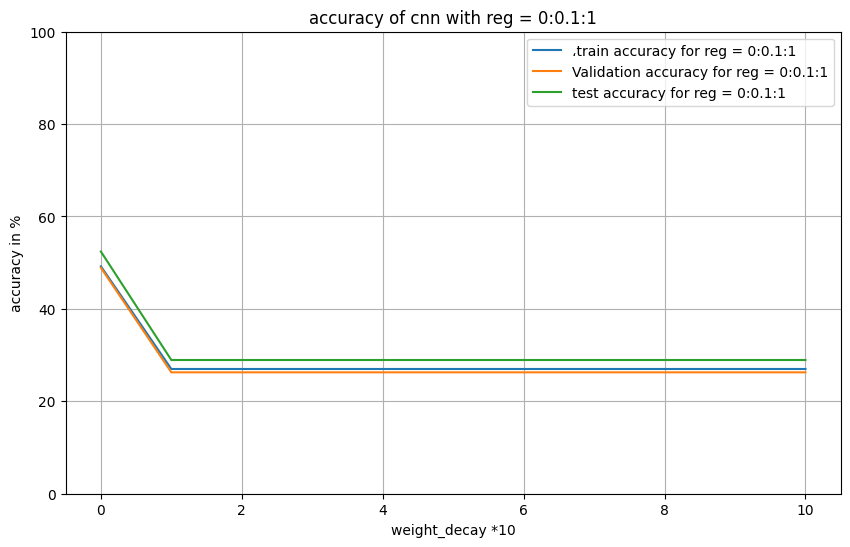

In [39]:
#plotting training, validation and test accuracies for ParametricCNN with change reg
fig, ax = plt.subplots(figsize=(10, 6))

max_accuracy_reg_train=[]
max_accuracy_reg_valid=[]
max_accuracy_reg_test=[]

for weight_decay in list(i/10 for i in range(11)):
  max_accuracy_reg_train.append(max(train_accuracy_logs_c1[int(weight_decay*10)]))
  max_accuracy_reg_valid.append(max(validation_accuracy_logs_c1[int(weight_decay*10)]))
  max_accuracy_reg_test.append(max(test_accuracy_logs_c1[int(weight_decay*10)]))

ax.plot(max_accuracy_reg_train, label='،train accuracy for reg = 0:0.1:1 ')
ax.plot(max_accuracy_reg_valid, label='Validation accuracy for reg = 0:0.1:1')
ax.plot(max_accuracy_reg_test, label='test accuracy for reg = 0:0.1:1')

ax.set_title('accuracy of cnn with reg = 0:0.1:1')
ax.set_xlabel('weight_decay *10')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

In [40]:
epoch_logs_c3=[]
loss_logs_c3 = []
train_accuracy_logs_c3 = []
test_accuracy_logs_c3 = []
validation_accuracy_logs_c3 = []

for weight_decay in list(i/1000 for i in range(20)):
    print(f'reg={weight_decay}')
    net_lr_scheduled_reg = ParametricCNN(lr=0.3, reg=weight_decay, device=device)
    net_lr_scheduled_reg.to(device)
    optimizer = net_lr_scheduled_reg.configure_optimizers()

    criterion = nn.CrossEntropyLoss()

    epochs = 50

    epoch_log_sch_reg = []
    loss_log_sch_reg = []
    train_accuracy_log_sch_reg = []
    test_accuracy_log_sch_reg = []
    validation_accuracy_log_sch_reg = []

    scheduler = StepLR(optimizer, step_size=25, gamma=0.25)

    for epoch in range(epochs):  
        print('\n'+f'Starting Epoch: {epoch+1}...')

        running_loss = 0.0

        print("Learning rate: ", optimizer.param_groups[0]['lr'])

        for i, data in enumerate(trainloader, 0):
            inputs, labels = data

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = net_lr_scheduled_reg(inputs) # Forward Propagation 
            loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
            loss.backward() # Back propagate to obtain the new gradients for all nodes
            optimizer.step() # Update the gradients/weights

            running_loss += loss.item()

        correct = 0 
        total = 0 

        with torch.no_grad():
            for data in trainloader:
                images, labels = data

                images = images.to(device)
                labels = labels.to(device)

                outputs = net_lr_scheduled_reg(images)

                _, predicted = torch.max(outputs.data, dim = 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            train_accuracy = 100 * correct / total
            epoch_num = epoch + 1
            NumOfBatches=len(train_data)/batch_size
            actual_loss = running_loss / NumOfBatches

            print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
            running_loss = 0.0

        correct = 0 
        total = 0 

        with torch.no_grad():
            for data in valloader:
                images, labels = data

                images = images.to(device)
                labels = labels.to(device)

                outputs = net_lr_scheduled_reg(images)

                _, predicted = torch.max(outputs.data, dim = 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            validation_accuracy = 100 * correct / total

            print(f'Validation Accuracy = {validation_accuracy:.3f}%')

        correct = 0 
        total = 0 

        with torch.no_grad():
            for data in testloader:
                images, labels = data

                images = images.to(device)
                labels = labels.to(device)

                outputs = net_lr_scheduled_reg(images)

                _, predicted = torch.max(outputs.data, dim = 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            test_accuracy = 100 * correct / total

            print(f'Test Accuracy = {test_accuracy:.3f}%')

        epoch_log_sch_reg.append(epoch_num)
        loss_log_sch_reg.append(actual_loss)
        train_accuracy_log_sch_reg.append(train_accuracy)
        validation_accuracy_log_sch_reg.append(validation_accuracy)
        test_accuracy_log_sch_reg.append(test_accuracy)

        # adjusting learning rate using scheduler
        scheduler.step()

    epoch_logs_c3.append(epoch_log_sch_reg)
    loss_logs_c3.append(loss_log_sch_reg)
    train_accuracy_logs_c3.append(train_accuracy_log_sch_reg)
    test_accuracy_logs_c3.append(test_accuracy_log_sch_reg)
    validation_accuracy_logs_c3.append(validation_accuracy_log_sch_reg)
    
    print('Finished Training')

print('finished reg parameter values')


reg=0.0


ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)


Starting Epoch: 1...
Learning rate:  0.3
Loss: 2.190
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%

Starting Epoch: 2...
Learning rate:  0.3
Loss: 2.027
Train Accuracy = 48.515%
Validation Accuracy = 47.606%
Test Accuracy = 52.026%

Starting Epoch: 3...
Learning rate:  0.3
Loss: 1.894
Train Accuracy = 48.538%
Validation Accuracy = 47.790%
Test Accuracy = 52.026%

Starting Epoch: 4...
Learning rate:  0.3
Loss: 1.891
Train Accuracy = 48.884%
Validation Accuracy = 48.711%
Test Accuracy = 52.118%

Starting Epoch: 5...
Learning rate:  0.3
Loss: 1.896
Train Accuracy = 48.619%
Validation Accuracy = 48.066%
Test Accuracy = 51.473%

Starting Epoch: 6...
Learning rate:  0.3
Loss: 1.888
Train Accuracy = 48.814%
Validation Accuracy = 48.619%
Test Accuracy = 52.118%

Starting Epoch: 7...
Learning rate:  0.3
Loss: 1.887
Train Accuracy = 48.227%
Validation Accuracy = 47.145%
Test Accuracy = 51.197%

Starting Epoch: 8...
Learning rate:  0.3
Loss: 1.887
Train Accuracy 

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)


Starting Epoch: 1...
Learning rate:  0.3
Loss: 2.191
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 2...
Learning rate:  0.3
Loss: 2.059
Train Accuracy = 43.750%
Validation Accuracy = 41.529%
Test Accuracy = 46.777%

Starting Epoch: 3...
Learning rate:  0.3
Loss: 1.879
Train Accuracy = 60.543%
Validation Accuracy = 57.182%
Test Accuracy = 64.088%

Starting Epoch: 4...
Learning rate:  0.3
Loss: 1.777
Train Accuracy = 62.155%
Validation Accuracy = 58.656%
Test Accuracy = 64.549%

Starting Epoch: 5...
Learning rate:  0.3
Loss: 1.744
Train Accuracy = 62.442%
Validation Accuracy = 59.669%
Test Accuracy = 65.838%

Starting Epoch: 6...
Learning rate:  0.3
Loss: 1.763
Train Accuracy = 62.166%
Validation Accuracy = 59.116%
Test Accuracy = 65.285%

Starting Epoch: 7...
Learning rate:  0.3
Loss: 2.069
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 8...
Learning rate:  0.3
Loss: 2.106
Train Accuracy 

...


Starting Epoch: 1...
Learning rate:  0.3
Loss: 2.192
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 2...
Learning rate:  0.3
Loss: 2.176
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 3...
Learning rate:  0.3
Loss: 2.162
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 4...
Learning rate:  0.3
Loss: 2.146
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 5...
Learning rate:  0.3
Loss: 2.121
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 6...
Learning rate:  0.3
Loss: 2.096
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 7...
Learning rate:  0.3
Loss: 2.089
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 8...
Learning rate:  0.3
Loss: 2.089
Train Accuracy 

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)


Starting Epoch: 1...
Learning rate:  0.3
Loss: 2.194
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 2...
Learning rate:  0.3
Loss: 2.177
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 3...
Learning rate:  0.3
Loss: 2.159
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 4...
Learning rate:  0.3
Loss: 2.103
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 5...
Learning rate:  0.3
Loss: 2.070
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 6...
Learning rate:  0.3
Loss: 2.014
Train Accuracy = 44.141%
Validation Accuracy = 42.357%
Test Accuracy = 47.145%

Starting Epoch: 7...
Learning rate:  0.3
Loss: 1.984
Train Accuracy = 48.078%
Validation Accuracy = 47.330%
Test Accuracy = 51.565%

Starting Epoch: 8...
Learning rate:  0.3
Loss: 1.969
Train Accuracy 

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)


Starting Epoch: 1...
Learning rate:  0.3
Loss: 2.192
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 2...
Learning rate:  0.3
Loss: 2.178
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 3...
Learning rate:  0.3
Loss: 2.165
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 4...
Learning rate:  0.3
Loss: 2.154
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 5...
Learning rate:  0.3
Loss: 2.141
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 6...
Learning rate:  0.3
Loss: 2.129
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 7...
Learning rate:  0.3
Loss: 2.115
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%

Starting Epoch: 8...
Learning rate:  0.3
Loss: 2.099
Train Accuracy 

Text(0.5, 1.0, 'accuracy of cnn with reg = 0:02')

Text(0.5, 0, 'weight_decay *500')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

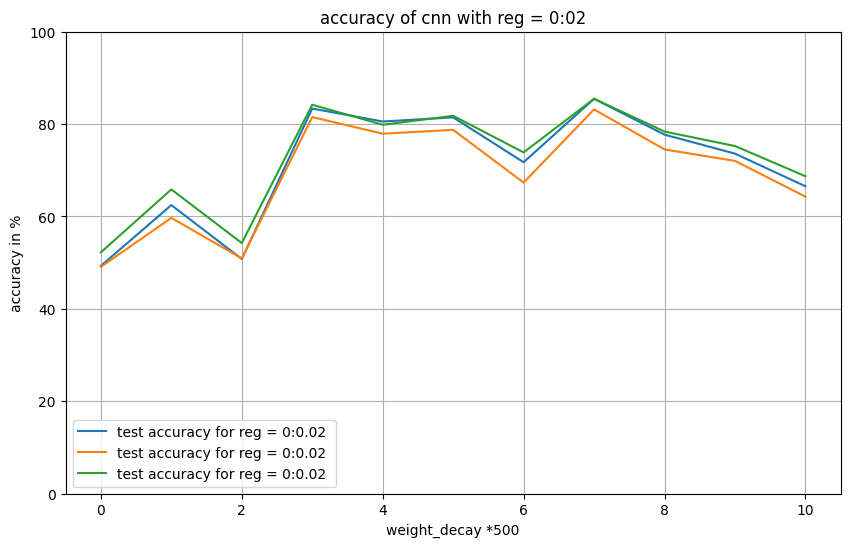

In [41]:
#plotting training, validation and test accuracies for ParametricCNN with change reg 0 - 0.02
fig, ax = plt.subplots(figsize=(10, 6))

max_accuracy_reg_train_1=[]
max_accuracy_reg_valid_1=[]
max_accuracy_reg_test_1=[]

for weight_decay in list(i/10 for i in range(11)):
  max_accuracy_reg_train_1.append(max(train_accuracy_logs_c3[int(weight_decay*10)]))
  max_accuracy_reg_valid_1.append(max(validation_accuracy_logs_c3[int(weight_decay*10)]))
  max_accuracy_reg_test_1.append(max(test_accuracy_logs_c3[int(weight_decay*10)]))

ax.plot(max_accuracy_reg_train_1, label='test accuracy for reg = 0:0.02 ')
ax.plot(max_accuracy_reg_valid_1, label='test accuracy for reg = 0:0.02')
ax.plot(max_accuracy_reg_test_1, label='test accuracy for reg = 0:0.02')

ax.set_title('accuracy of cnn with reg = 0:02')
ax.set_xlabel('weight_decay *500')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

#Part C-4

In [42]:
from torch.optim.lr_scheduler import StepLR

net_c4 = ParametricCNN(lr=0.3, reg=0.005 ,device=device)
net_c4.to(device)
optimizer = net_c4.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 200

epoch_log_c4 = []
loss_log_c4 = []
train_accuracy_log_c4 = []
test_accuracy_log_c4 = []
validation_accuracy_log_c4 = []

scheduler = StepLR(optimizer, step_size=50, gamma=0.6)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_c4(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_c4(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_c4(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_c4(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_c4.append(epoch_num)
    loss_log_c4.append(actual_loss)
    train_accuracy_log_c4.append(train_accuracy)
    validation_accuracy_log_c4.append(validation_accuracy)
    test_accuracy_log_c4.append(test_accuracy)
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.3
Loss: 2.190
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 2...
Learning rate:  0.3
Loss: 2.116
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 3...
Learning rate:  0.3
Loss: 1.994
Train Accuracy = 44.406%
Validation Accuracy = 43.094%
Test Accuracy = 47.790%
Starting Epoch: 4...
Learning rate:  0.3
Loss: 1.843
Train Accuracy = 59.450%
Validation Accuracy = 56.169%
Test Accuracy = 61.510%
Starting Epoch: 5...
Learning rate:  0.3
Loss: 1.817
Train Accuracy = 45.868%
Validation Accuracy = 44.843%
Test Accuracy = 49.079%
Starting Epoch: 6...
Learning rate:  0.3
Loss: 1.994
Train Accuracy = 59.105%
Validation Accuracy = 55.433%
Test Accuracy = 61.510%
Starting Epoch: 7...
Learning rate:  0.3
Loss: 1.790
Train Accuracy = 58.863%
Validation Accuracy = 55.709%
Test Accuracy = 61.142%
Starting Epoch: 8...
Learning rate:  0.3
Loss: 1.753
Train Accuracy = 64.457

Text(0.5, 1.0, 'train, validation and test accuracies for ParametricCNN with learning rate of 0.3 and sch = 0.6 and reg = 0.005')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

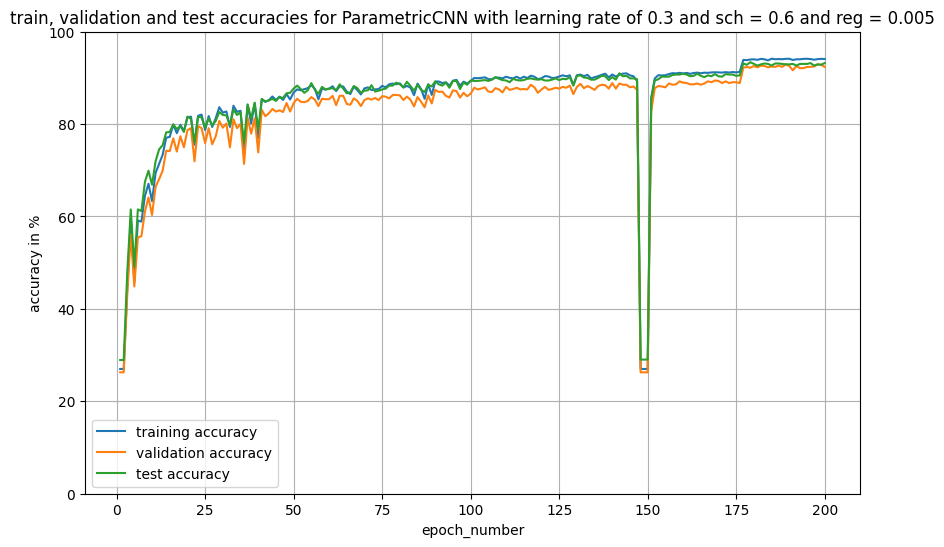

In [43]:
#plotting train, validation and test accuracies for ParametricCNN with learning rate of 0.3 and sch = 0.6 and reg = 0.005
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_c4, train_accuracy_log_c4, label='training accuracy')
ax.plot(epoch_log_c4, validation_accuracy_log_c4, label='validation accuracy')
ax.plot(epoch_log_c4, test_accuracy_log_c4, label='test accuracy')

ax.set_title('train, validation and test accuracies for ParametricCNN with learning rate of 0.3 and sch = 0.6 and reg = 0.005')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()

#Part D

#Part D-1

In [44]:
from torch.optim.lr_scheduler import StepLR

net_d1 = ParametricCNN(lr=0.3, reg=0.005 ,device=device)
net_d1.to(device)
optimizer = net_d1.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 300

epoch_log_d1 = []
loss_log_d1 = []
train_accuracy_log_d1 = []
test_accuracy_log_d1 = []
validation_accuracy_log_d1 = []
best_val_acc = 0.0
patience = 10
num_epochs_no_improvement = 0

scheduler = StepLR(optimizer, step_size=50, gamma=0.6)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_d1(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_d1(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_d1(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_d1(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_d1.append(epoch_num)
    loss_log_d1.append(actual_loss)
    train_accuracy_log_d1.append(train_accuracy)
    validation_accuracy_log_d1.append(validation_accuracy)
    test_accuracy_log_d1.append(test_accuracy)

    # check for early stopping
    if validation_accuracy > best_val_acc:
        best_val_acc = validation_accuracy
        num_epochs_no_improvement = 0
        torch.save(net_d1.state_dict(), 'best_model_params.pt')
    else:
        num_epochs_no_improvement += 1
        if num_epochs_no_improvement >= patience:
            print(f'Validation accuracy did not improve for {patience} epochs, stopping training.')
            break
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

ParametricCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.3
Loss: 2.187
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 2...
Learning rate:  0.3
Loss: 2.049
Train Accuracy = 43.773%
Validation Accuracy = 41.713%
Test Accuracy = 46.593%
Starting Epoch: 3...
Learning rate:  0.3
Loss: 1.895
Train Accuracy = 44.924%
Validation Accuracy = 44.107%
Test Accuracy = 48.435%
Starting Epoch: 4...
Learning rate:  0.3
Loss: 2.098
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 5...
Learning rate:  0.3
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 6...
Learning rate:  0.3
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 7...
Learning rate:  0.3
Loss: 2.106
Train Accuracy = 26.968%
Validation Accuracy = 26.243%
Test Accuracy = 28.913%
Starting Epoch: 8...
Learning rate:  0.3
Loss: 2.104
Train Accuracy = 26.968

Text(0.5, 1.0, 'train, validation and test accuracies for ParametricCNN with learning rate of 0.3 and sch = 0.6 and reg = 0.005 & early stopping')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

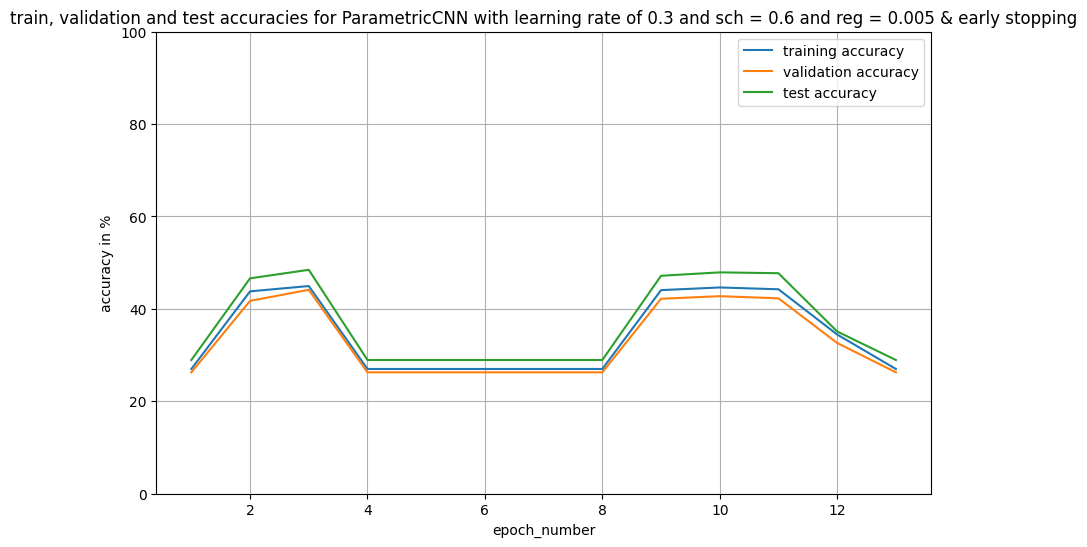

In [45]:
#plotting train, validation and test accuracies for ParametricCNN with learning rate of 0.3 and sch = 0.6 and reg = 0.005 & early stopping
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_d1, train_accuracy_log_d1, label='training accuracy')
ax.plot(epoch_log_d1, validation_accuracy_log_d1, label='validation accuracy')
ax.plot(epoch_log_d1, test_accuracy_log_d1, label='test accuracy')

ax.set_title('train, validation and test accuracies for ParametricCNN with learning rate of 0.3 and sch = 0.6 and reg = 0.005 & early stopping')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()